[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/D4san/gdaespec/blob/main/model-parameters/G-DAE-Example.ipynb)

# G-DAE Application Example
## A simulated Trappist-1e transmission spectra decontaminated by a G-DAE

<div align="center">
  <img src="https://raw.githubusercontent.com/D4san/gdaespec/main/gallery/G-DAE_logo.webp" alt="G-DAESpec logo" width="620"/>
</div>

This notebook applies the Earth-like G-DAE trained by [Duque-Castaño, Flor-Torres and Zuluaga (2026)](https://arxiv.org/abs/2602.10330) to one synthetic JWST/NIRSpec Prism observation from the retrieval campaign. The example uses a TRAPPIST-1e analogue with PHOENIX stellar contamination at $f_\mathrm{spot}=0.08$ and $f_\mathrm{fac}=0.54$.

The notebook loads the trained model, reads one noisy observation and its clean reference, reconstructs the decontaminated spectrum, and estimates the uncertainty associated with the reconstruction.

If you find this work useful, please cite our work:

> **Efficient reduction of stellar contamination and noise in planetary transmission spectra using neural networks**, Duque-Castaño, Zuluaga & Flor-Torres, arXiv: [2602.10330](https://arxiv.org/abs/2602.10330)

## Before start

If you are running this notebook in Google Colab, execute the following setup cell first:

In [1]:
import sys
if "google.colab" in sys.modules:
    %pip install -q --force-reinstall --no-cache-dir -r https://raw.githubusercontent.com/D4san/gdaespec/main/model-parameters/requirements.txt
    %pip uninstall -y -q jax jaxlib
    !rm -rf gdaespec data
    !git clone --depth 1 https://github.com/D4san/gdaespec.git
    !cp -r gdaespec/model-parameters/data ./data
    try:
        import numpy as np
        from tensorflow import keras
        print("Colab setup OK.")
    except Exception as e:
        print("Packages installed, but runtime restart is required.")
        print(f"Reason: {e}")
        print("Go to Runtime > Restart session, then run all cells again.")
else:
    print("Not running in Colab. Setup skipped.")

Not running in Colab. Setup skipped.


These are the required packages:

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras

## Inputs

The example uses two small text files in `examples/data/`:

- `observation.dat`: wavelength, half-bin width, noisy transit depth, and instrumental uncertainty.
- `reference.dat`: wavelength and clean reference transit depth binned onto the same grid.


In [3]:
DATA_DIR = "data"
MODEL = "G-DAE-EarthLike.keras"

T_PASSES_DROPOUT = 50
EPS_RANGE = 1.0e-12
EPS_SIGMA = 1.0e-12


## Load the Example

The observation and reference are already on the same wavelength grid. They are reversed once after loading to match the spectral order used by the trained G-DAE.


In [4]:
observation = np.loadtxt(f"{DATA_DIR}/observation.dat").astype(np.float32)[::-1]
reference = np.loadtxt(f"{DATA_DIR}/reference.dat").astype(np.float32)[::-1]

wavelength_um = observation[:, 0]
noisy_depth = observation[:, 2]
sigma_inst = observation[:, 3]
clean_reference = reference[:, 1]

print("Model:", MODEL)
print("Channels:", wavelength_um.size)
print("Wavelength range [um]:", float(wavelength_um.min()), "-", float(wavelength_um.max()))


Model: G-DAE-EarthLike.keras
Channels: 385
Wavelength range [um]: 0.6988052725791931 - 5.2975687980651855


## Normalization

The G-DAE receives spectra normalized independently to the $[0,1]$ interval. After prediction, the output is mapped back to transit-depth units using the clean reference scale in this controlled example.


In [5]:
def as_2d_spectra(values: np.ndarray) -> np.ndarray:
    """Return spectra as a float32 array with shape (n_samples, n_waves)."""
    arr = np.asarray(values, dtype=np.float32)
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.ndim != 2:
        raise ValueError(f"Expected a 1D or 2D spectrum array, got shape {arr.shape}.")
    return arr


def row_min_max_normalize(values: np.ndarray) -> np.ndarray:
    """Normalize each spectrum independently to the [0, 1] interval."""
    arr = as_2d_spectra(values)
    v_min = arr.min(axis=1, keepdims=True)
    v_rng = arr.max(axis=1, keepdims=True) - v_min
    safe_rng = np.where(v_rng <= EPS_RANGE, 1.0, v_rng).astype(np.float32)
    normalized = (arr - v_min) / safe_rng
    normalized[v_rng[:, 0] <= EPS_RANGE] = 0.0
    return normalized.astype(np.float32)


def row_min_max_denormalize(values_norm: np.ndarray, reference: np.ndarray) -> np.ndarray:
    """Denormalize normalized spectra using row-wise min/max from a reference."""
    norm = as_2d_spectra(values_norm)
    ref = as_2d_spectra(reference)
    ref_min = ref.min(axis=1, keepdims=True)
    ref_rng = ref.max(axis=1, keepdims=True) - ref_min
    out = norm * ref_rng + ref_min
    out[ref_rng[:, 0] <= EPS_RANGE] = ref_min[ref_rng[:, 0] <= EPS_RANGE]
    return out.astype(np.float32)


## Decontamination and Uncertainty

MC Dropout keeps dropout active during repeated forward passes. The mean of those passes is the reconstructed spectrum, while their scatter estimates epistemic uncertainty. The aleatoric term represents the instrumental noise budget and is set to $0.5\,\sigma_\mathrm{inst}$; both terms are added in quadrature.


In [6]:
def reconstruct_mc_dropout(
    model: keras.Model,
    spectrum: np.ndarray,
    denorm_reference: np.ndarray,
    t_passes: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Return MC Dropout mean reconstruction and epistemic uncertainty."""
    x_norm = row_min_max_normalize(spectrum)
    reconstructions = []

    for _ in range(int(t_passes)):
        y_norm = model(x_norm, training=True).numpy().astype(np.float32)
        reconstructions.append(row_min_max_denormalize(y_norm, denorm_reference))

    samples = np.stack(reconstructions, axis=0)
    return samples.mean(axis=0), samples.std(axis=0, ddof=1)


def chi2_reduced(y_true: np.ndarray, y_pred: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    """Compute reduced chi-square row by row with p=0."""
    true = as_2d_spectra(y_true)
    pred = as_2d_spectra(y_pred)
    sig = np.asarray(sigma, dtype=np.float32)
    if sig.ndim == 1:
        sig = np.broadcast_to(sig[None, :], true.shape)
    return np.sum(((pred - true) / np.clip(sig, EPS_SIGMA, np.inf)) ** 2, axis=1) / true.shape[1]


In [7]:
model = keras.models.load_model(f"{DATA_DIR}/{MODEL}")

x_noisy = as_2d_spectra(noisy_depth)
x_clean = as_2d_spectra(clean_reference)

recon_mean, sigma_epi = reconstruct_mc_dropout(
    model=model,
    spectrum=x_noisy,
    denorm_reference=x_clean,
    t_passes=T_PASSES_DROPOUT,
)

sigma_ale = np.broadcast_to(0.5 * sigma_inst[None, :], recon_mean.shape).astype(np.float32)
sigma_total = np.sqrt(sigma_ale**2 + sigma_epi**2 + EPS_SIGMA**2)

chi2_noisy = chi2_reduced(x_clean, x_noisy, sigma_inst)
chi2_recon = chi2_reduced(x_clean, recon_mean, sigma_total)

print(f"MC Dropout passes: {T_PASSES_DROPOUT}")
print(f"chi2_r(noisy vs clean, sigma_inst): {float(chi2_noisy[0]):.3f}")
print(f"chi2_r(recon vs clean, sigma_total): {float(chi2_recon[0]):.3f}")
print(f"median sigma_epi / sigma_inst: {float(np.median(sigma_epi[0] / sigma_inst)):.3f}")
print(f"median sigma_total / sigma_inst: {float(np.median(sigma_total[0] / sigma_inst)):.3f}")


MC Dropout passes: 50
chi2_r(noisy vs clean, sigma_inst): 24.855
chi2_r(recon vs clean, sigma_total): 0.011
median sigma_epi / sigma_inst: 0.017
median sigma_total / sigma_inst: 0.500


## Reconstruction Plot

The residual panel compares the reconstructed spectrum with the known clean reference. The gray band is the total uncertainty propagated from the instrumental and MC Dropout terms.


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


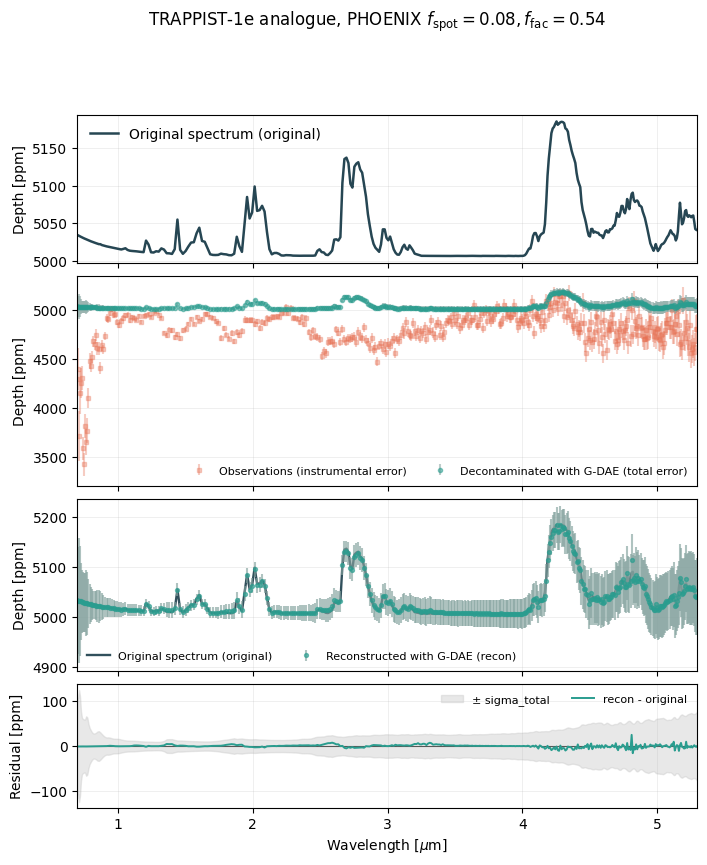

In [8]:
order = np.argsort(wavelength_um)
waves = wavelength_um[order]
clean = x_clean[0, order]
noisy = x_noisy[0, order]
recon = recon_mean[0, order]
inst = sigma_inst[order]
total = sigma_total[0, order]

fig, (ax_top, ax_mid, ax_cmp, ax_res) = plt.subplots(
    4,
    1,
    figsize=(8, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1.7, 1.4, 1.0], "hspace": 0.08},
)

ax_top.plot(waves, clean * 1e6, color="#264653", lw=1.8, label="Original spectrum (original)")
ax_top.set_ylabel("Depth [ppm]")
ax_top.legend(frameon=False, loc="best")

ax_mid.errorbar(
    waves,
    noisy * 1e6,
    yerr=inst * 1e6,
    fmt="s",
    ms=3,
    alpha=0.35,
    color="#E76F51",
    label="Observations (instrumental error)",
)
ax_mid.errorbar(
    waves,
    recon * 1e6,
    yerr=total * 1e6,
    fmt="o",
    ms=3,
    alpha=0.55,
    color="#2A9D8F",
    ecolor="#85A39F",
    label="Decontaminated with G-DAE (total error)",
)
ax_mid.set_ylabel("Depth [ppm]")
ax_mid.legend(frameon=False, loc="best", ncol=2, fontsize=8)

# Comparison panel: Original spectrum (original) vs G-DAE reconstruction (with G-DAE error bars).
ax_cmp.plot(
    waves,
    clean * 1e6,
    color="#264653",
    lw=1.7,
    alpha=0.95,
    label="Original spectrum (original)",
)
ax_cmp.errorbar(
    waves,
    recon * 1e6,
    yerr=total * 1e6,
    fmt="o",
    ms=2.8,
    alpha=0.65,
    color="#2A9D8F",
    ecolor="#85A39F",
    label="Reconstructed with G-DAE (recon)",
)
ax_cmp.set_ylabel("Depth [ppm]")
ax_cmp.legend(frameon=False, loc="lower left", ncol=2, fontsize=8)

residual = (recon - clean) * 1e6
ax_res.axhline(0.0, color="black", lw=0.8, alpha=0.6)
ax_res.fill_between(
    waves,
    -total * 1e6,
    total * 1e6,
    color="#cccccc",
    alpha=0.45,
    label="± sigma_total",
)
ax_res.plot(waves, residual, color="#2A9D8F", lw=1.4, label="recon - original")
ax_res.set_xlabel(r"Wavelength [$\mu$m]")
ax_res.set_ylabel("Residual [ppm]")
ax_res.legend(frameon=False, loc="best", ncol=2, fontsize=8)

for ax in (ax_top, ax_mid, ax_cmp, ax_res):
    ax.grid(True, alpha=0.2, lw=0.7)
    ax.margins(x=0)

fig.suptitle(
    r"TRAPPIST-1e analogue, PHOENIX $f_\mathrm{spot}=0.08, f_\mathrm{fac}=0.54$",
    y=0.97,
    fontsize=12,
    va="bottom",
)
plt.savefig("G-DAE-Reconstruction-TRAPPIST1e.png", dpi=300, bbox_inches="tight")
plt.show()

And voilà!